# Load Packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pickle as pickle
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.metrics import matthews_corrcoef, make_scorer, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

from classical_data_processing import get_vectorized_data

# Import Data

In [2]:
X_train, y_train, X_val, y_val, X_test, y_test = get_vectorized_data()

In [3]:
class_names = pd.read_csv("../data/class_names.csv", index_col=0).to_numpy()
class_names

array([['Irrelevant'],
       ['Negative'],
       ['Neutral'],
       ['Positive']], dtype=object)

# Model

In [4]:
forest = RandomForestClassifier(random_state=42)
matthews_scorer = make_scorer(matthews_corrcoef)

## Hyperparameter Search

In [5]:
param_grid = {
    "n_estimators": [10, 20, 50, 100, 200],
    "min_samples_split": [2, 3, 4]
}

grid_search = GridSearchCV(forest, param_grid, scoring=matthews_scorer, verbose=3)
grid_search.fit(X_train, y_train)

grid_search.cv_results_

Fitting 5 folds for each of 15 candidates, totalling 75 fits
[CV 1/5] END min_samples_split=2, n_estimators=10;, score=0.868 total time=  13.3s
[CV 2/5] END min_samples_split=2, n_estimators=10;, score=0.864 total time=  14.2s
[CV 3/5] END min_samples_split=2, n_estimators=10;, score=0.870 total time=  14.2s
[CV 4/5] END min_samples_split=2, n_estimators=10;, score=0.886 total time=  14.6s
[CV 5/5] END min_samples_split=2, n_estimators=10;, score=0.917 total time=  13.7s
[CV 1/5] END min_samples_split=2, n_estimators=20;, score=0.890 total time=  26.9s
[CV 2/5] END min_samples_split=2, n_estimators=20;, score=0.889 total time=  27.2s
[CV 3/5] END min_samples_split=2, n_estimators=20;, score=0.895 total time=  25.3s
[CV 4/5] END min_samples_split=2, n_estimators=20;, score=0.905 total time=  24.0s
[CV 5/5] END min_samples_split=2, n_estimators=20;, score=0.930 total time=  24.1s
[CV 1/5] END min_samples_split=2, n_estimators=50;, score=0.904 total time=  55.0s
[CV 2/5] END min_samples_s

{'mean_fit_time': array([ 13.89534984,  25.26478024,  55.44542451, 109.52613316,
        214.66302896,  11.103547  ,  21.86390586,  53.55395865,
        106.77934723, 213.41084652,  10.92374282,  21.52202134,
         53.36894555, 106.75131421, 212.45633168]),
 'std_fit_time': array([0.44829871, 1.34479779, 2.33787511, 1.02530512, 0.70021758,
        0.2065249 , 0.25786156, 0.25450723, 0.57439082, 0.41931188,
        0.13824146, 0.25513368, 0.23733014, 0.4535133 , 0.69901415]),
 'mean_score_time': array([0.20550508, 0.34348707, 0.62150683, 1.18715343, 2.308114  ,
        0.15166955, 0.27134171, 0.61429453, 1.19420033, 2.319977  ,
        0.1573667 , 0.26483865, 0.62315292, 1.16333098, 2.32867947]),
 'std_score_time': array([0.01582292, 0.01996991, 0.01232602, 0.02678207, 0.03385846,
        0.00440005, 0.00742407, 0.02369421, 0.03072218, 0.02444452,
        0.01083527, 0.00953108, 0.02608484, 0.02001328, 0.05407795]),
 'param_min_samples_split': masked_array(data=[2, 2, 2, 2, 2, 3, 3, 

In [6]:
best_model = grid_search.best_estimator_

## Training

In [7]:
train_score = best_model.score(X_train, y_train)

print("Training Score: ", train_score)

Training Score:  0.9813233480980866


## Validation

In [8]:
val_score = best_model.score(X_val, y_val)

print("Validation Score: ", val_score)

Validation Score:  0.9366666666666666


## Test

In [9]:
test_score = best_model.score(X_test, y_test)

print("Test Score: ", test_score)

Test Score:  0.952


# Display Results

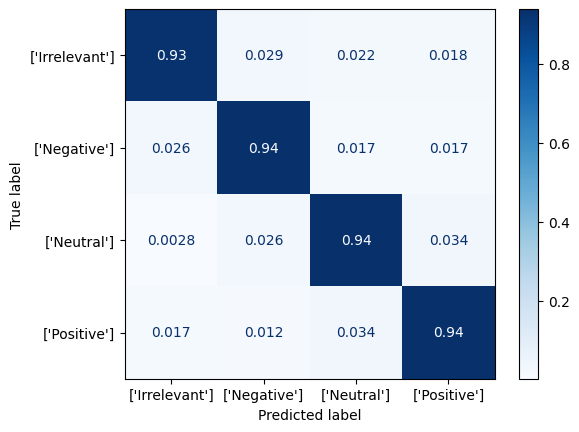

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
titles = [
    ("Confusion Matrix (without normalization)", None),
    ("Confusion Matrix (normalized)", "true")
]

display = ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_val,
    y_val,
    display_labels=class_names,
    cmap=plt.cm.Blues,
    normalize="true"
)

In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

y_pred = best_model.predict(X_test)

In [25]:
# MCC
matthews_corrcoef(y_test, y_pred)

np.float64(0.9353332946235705)

In [22]:
# PRECISION
precision_score(y_test, y_pred, average="macro")

0.9546704671803234

In [23]:
# RECALL
recall_score(y_test, y_pred, average="macro")

0.9495216322436517

In [24]:
# F1 SCORE
f1_score(y_test, y_pred, average="macro")

0.9518296516949424